<a href="https://colab.research.google.com/github/timfan705/CAmarket/blob/main/cmpe188_CAmarket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step needed to be made:**
* Data Aquisition - we need more data sets; i think 4 is a safe bet
* Key features we want to include in our ML App (Location, Median Income, Average house price given size like 3b2b, etc)
* Which ML model to use
* Actual Coding (Training model, frontend)
* Testing and Validation


# Data Aquisition Step


In [3]:
# installing dependancies
!pip install pandas scikit-learn --quiet

In [4]:
# adding imports
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import os

In [5]:
# creating a directory structure
os.makedirs("data/raw", exist_ok=True)
print("Directories created")

Directories created


In [6]:
# loading the sklearn dataset
sklearn_housing = fetch_california_housing(as_frame=True)
df_sklearn = sklearn_housing.frame
df_sklearn.rename(columns={"MedHouseVal": "median_house_value"}, inplace=True)

print(f" sklearn loaded | Shape: {df_sklearn.shape}")
print(df_sklearn.head())

 sklearn loaded | Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  median_house_value  
0    -122.23               4.526  
1    -122.22               3.585  
2    -122.24               3.521  
3    -122.25               3.413  
4    -122.25               3.422  


In [7]:
# importing the zillow csv (has to be downloaded on local device and uploaded from local device)
from google.colab import files

uploaded = files.upload()
zillow_filename = list(uploaded.keys())[0]

# Read raw CSV
df_zillow_raw = pd.read_csv(zillow_filename)

print("Raw Zillow shape:", df_zillow_raw.shape)
print(df_zillow_raw.head())

Saving zillow.csv to zillow (1).csv
Raw Zillow shape: (895, 320)
   RegionID  SizeRank       RegionName RegionType StateName     2000-01-31  \
0    102001         0    United States    country       NaN  122723.314722   
1    394913         1     New York, NY        msa        NY  217784.554624   
2    753899         2  Los Angeles, CA        msa        CA  224762.443660   
3    394463         3      Chicago, IL        msa        IL  153387.535332   
4    394514         4       Dallas, TX        msa        TX  129543.865799   

      2000-02-29     2000-03-31     2000-04-30     2000-05-31  ...  \
0  122939.224374  123206.984135  123781.276262  124442.217647  ...   
1  218710.016103  219644.049023  221536.761145  223496.730091  ...   
2  225598.845127  226712.923903  228929.566423  231353.878418  ...   
3  153529.527506  153799.954104  154472.708272  155281.950617  ...   
4  129601.565090  129667.896331  129840.151596  130067.265447  ...   

      2025-06-30     2025-07-31     2025-08-3

In [8]:
# Filter for California only
df_zillow_ca = df_zillow_raw[df_zillow_raw["StateName"] == "California"].copy()

# Identify date columns (they follow YYYY-MM-DD format)
date_cols = [col for col in df_zillow_ca.columns if col.startswith("20")]
meta_cols = [col for col in df_zillow_ca.columns if not col.startswith("20")]

# Melt from wide to long format
df_zillow_long = df_zillow_ca.melt(
    id_vars=meta_cols,
    value_vars=date_cols,
    var_name="date",
    value_name="zillow_median_price"
)

# Convert date column to datetime
df_zillow_long["date"] = pd.to_datetime(df_zillow_long["date"])

# Keep only the most recent price per region
df_zillow_latest = (
    df_zillow_long
    .sort_values("date", ascending=False)
    .groupby("RegionName")
    .first()
    .reset_index()
)[["RegionName", "zillow_median_price"]]

print(f"Zillow CA latest prices | Shape: {df_zillow_latest.shape}")
print(df_zillow_latest.head())

Zillow CA latest prices | Shape: (0, 2)
Empty DataFrame
Columns: [RegionName, zillow_median_price]
Index: []


# Data Cleaning and Merging Step

In [9]:
!pip install geopy --quiet

In [10]:
# Check for nulls and data types
# first inspect the sklearn dataset
print(" sklearn Dataset ")
print(df_sklearn.shape)
print(df_sklearn.isnull().sum())
print(df_sklearn.dtypes)
print(df_sklearn.describe())

# second inspect zillow data set
print(" Zillow Dataset ")
print(df_zillow_latest.shape)
print(df_zillow_latest.isnull().sum())
print(df_zillow_latest.head(10))

 sklearn Dataset 
(20640, 9)
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
median_house_value    0
dtype: int64
MedInc                float64
HouseAge              float64
AveRooms              float64
AveBedrms             float64
Population            float64
AveOccup              float64
Latitude              float64
Longitude             float64
median_house_value    float64
dtype: object
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079  

In [11]:
# because sklearn dataset is in longitude/lattitude format, we need to convert
# zillow uses region names, so we need to convert the sklearn lat/lon coordinates
# into city names so we can match them to Zillow's city names.

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

geolocator = Nominatim(user_agent="housing_predictor")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def get_city(lat, lon):
    try:
        location = reverse(f"{lat}, {lon}", exactly_one=True)
        address = location.raw.get("address", {})
        # Try city first, fall back to town or county
        return (
            address.get("city") or
            address.get("town") or
            address.get("county", "Unknown")
        )
    except:
        return "Unknown"

# NOTE: This runs on a sample to avoid hitting API rate limits
# Run on full dataset once confirmed working
sample_df = df_sklearn.sample(100, random_state=42).copy()
sample_df["city"] = sample_df.apply(
    lambda row: get_city(row["Latitude"], row["Longitude"]), axis=1
)

print("City mapping complete")
print(sample_df[["Latitude", "Longitude", "city"]].head(10))

City mapping complete
       Latitude  Longitude           city
20046     36.06    -119.01    Porterville
3024      35.14    -119.46    Kern County
15663     37.80    -122.44  San Francisco
20484     34.28    -118.72    Simi Valley
9814      36.62    -121.93  Pacific Grove
13311     34.08    -117.61        Ontario
7113      33.89    -118.02      La Mirada
7668      33.92    -118.08        Norwalk
18246     37.39    -122.08  Mountain View
5723      34.18    -118.23       Glendale


In [12]:
def map_to_region(lat, lon):
    if lat >= 37.0 and lon <= -121.5:
        return "san francisco bay area"
    elif lat >= 34.0 and lat < 34.3 and lon >= -118.5:
        return "los angeles"
    elif lat >= 32.5 and lat < 33.5 and lon >= -117.5:
        return "san diego"
    elif lat >= 38.5 and lon <= -121.5:
        return "sacramento"
    elif lat >= 36.5 and lat < 37.0:
        return "fresno"
    elif lat >= 35.0 and lat < 36.5:
        return "bakersfield"
    elif lat >= 33.5 and lat < 34.0:
        return "riverside"
    else:
        return "other california"

df_sklearn["city"] = df_sklearn.apply(
    lambda row: map_to_region(row["Latitude"], row["Longitude"]), axis=1
)

print("Region mapping complete")
print(df_sklearn["city"].value_counts())

Region mapping complete
city
san francisco bay area    5432
riverside                 4347
los angeles               3819
other california          3531
san diego                 1736
fresno                     901
bakersfield                874
Name: count, dtype: int64


In [13]:
df_sklearn["city_clean"] = df_sklearn["city"].str.lower().str.strip()
df_zillow_latest["city_clean"] = df_zillow_latest["RegionName"].str.lower().str.strip()

print("City names standardized")

City names standardized


In [14]:
# Merge Data Sets

df_merged = pd.merge(
    df_sklearn,
    df_zillow_latest[["city_clean", "zillow_median_price"]],
    on="city_clean",
    how="left"  # Keep all sklearn rows even if no Zillow match
)

print(f"Merged dataset shape: {df_merged.shape}")
print(f"Zillow price matched: {df_merged['zillow_median_price'].notnull().sum()} rows")
print(df_merged.head())

Merged dataset shape: (20640, 12)
Zillow price matched: 0 rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  median_house_value                    city  \
0    -122.23               4.526  san francisco bay area   
1    -122.22               3.585  san francisco bay area   
2    -122.24               3.521  san francisco bay area   
3    -122.25               3.413  san francisco bay area   
4    -122.25               3.422  san francisco bay area   

               city_clean  zillow_median_price  
0  san francisco bay area                  NaN  
1  san francisco bay 

In [15]:
# handling null cases (can't map / match)
# For rows where Zillow had no match, fill with median price

zillow_median = df_merged["zillow_median_price"].median()
df_merged["zillow_median_price"].fillna(zillow_median, inplace=True)

# Drop any remaining nulls in other columns
df_merged.dropna(inplace=True)

print(f"Nulls handled | Final shape: {df_merged.shape}")
print(df_merged.isnull().sum())

Nulls handled | Final shape: (0, 12)
MedInc                 0
HouseAge               0
AveRooms               0
AveBedrms              0
Population             0
AveOccup               0
Latitude               0
Longitude              0
median_house_value     0
city                   0
city_clean             0
zillow_median_price    0
dtype: int64


/tmp/ipykernel_21585/3089216662.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged["zillow_median_price"].fillna(zillow_median, inplace=True)


In [16]:
# create a new save file for a merged dataset

os.makedirs("data/processed", exist_ok=True)
df_merged.to_csv("data/processed/merged_housing.csv", index=False)

print("Merged dataset saved to data/processed/merged_housing.csv")
print(df_merged.head())

Merged dataset saved to data/processed/merged_housing.csv
Empty DataFrame
Columns: [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude, median_house_value, city, city_clean, zillow_median_price]
Index: []


# Visualization of Current Dataset

In [17]:
!pip install matplotlib seaborn folium --quiet

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# Set default plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

=== Dataset Overview ===
Shape: (0, 12)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'median_house_value', 'city', 'city_clean', 'zillow_median_price']

Basic Statistics:


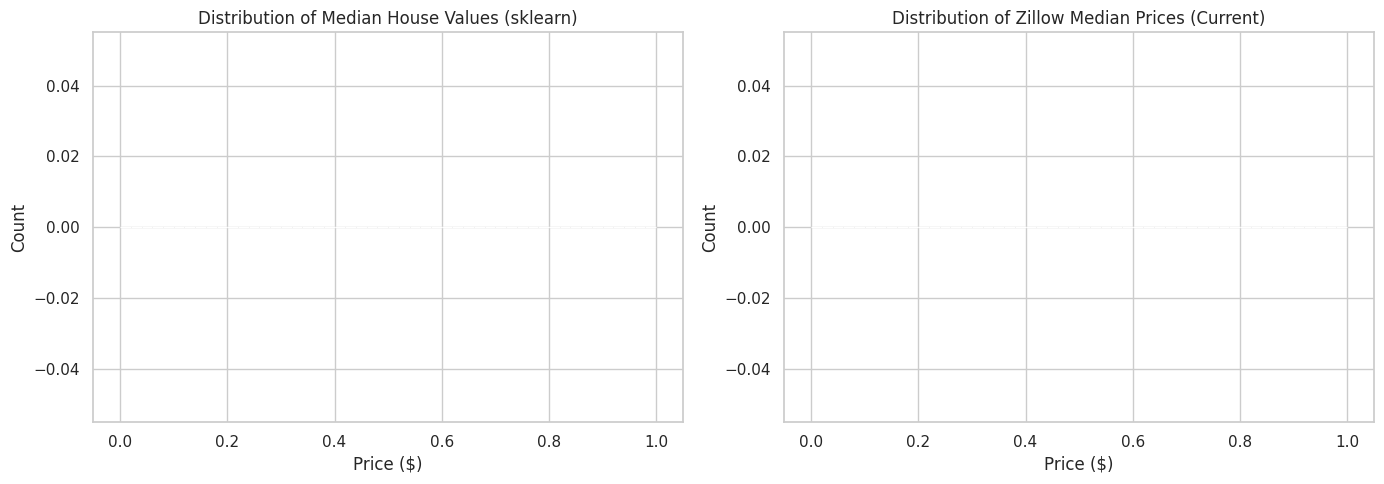

Price distribution plotted


In [19]:
print("=== Dataset Overview ===")
print(f"Shape: {df_merged.shape}")
print(f"\nColumn Names:\n{df_merged.columns.tolist()}")
print(f"\nBasic Statistics:")
df_merged.describe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sklearn prices (1990)
axes[0].hist(df_merged["median_house_value"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Median House Values (sklearn)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

# Zillow prices (current)
axes[1].hist(df_merged["zillow_median_price"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Zillow Median Prices (Current)")
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_price_distribution.png")
plt.show()
print("Price distribution plotted")

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


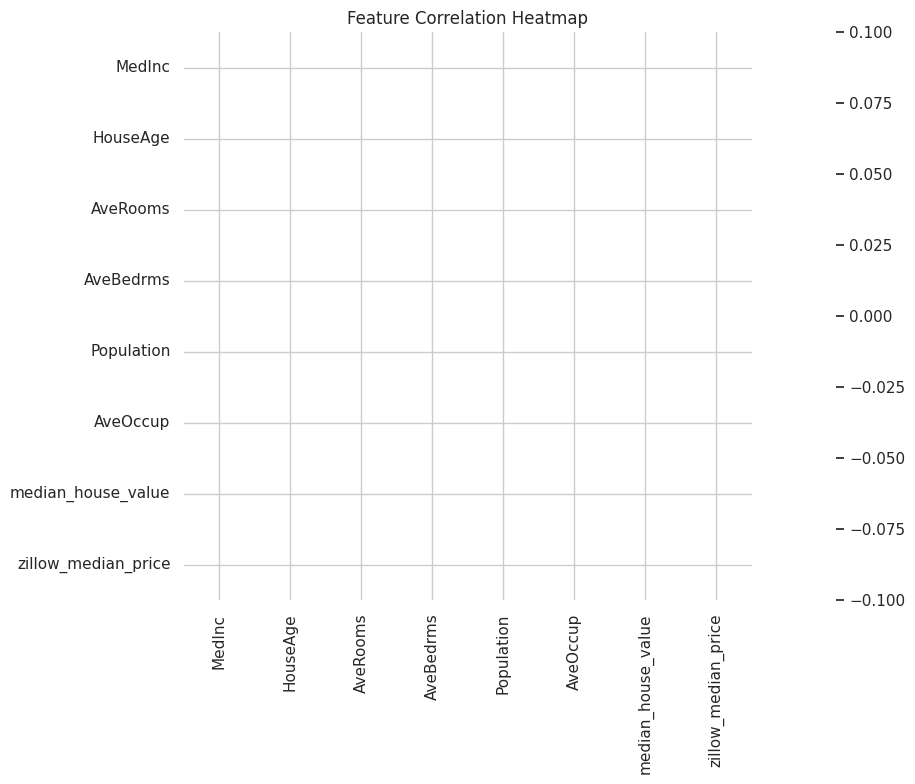

Correlation heatmap plotted


In [20]:
# which features are most related to house prices
# columns that have a high correlation with median_house_value or zillow_median_price

# Select only numeric columns
numeric_cols = df_merged.select_dtypes(include=[np.number]).drop(
    columns=["Latitude", "Longitude"]
)

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png")
plt.show()
print("Correlation heatmap plotted")

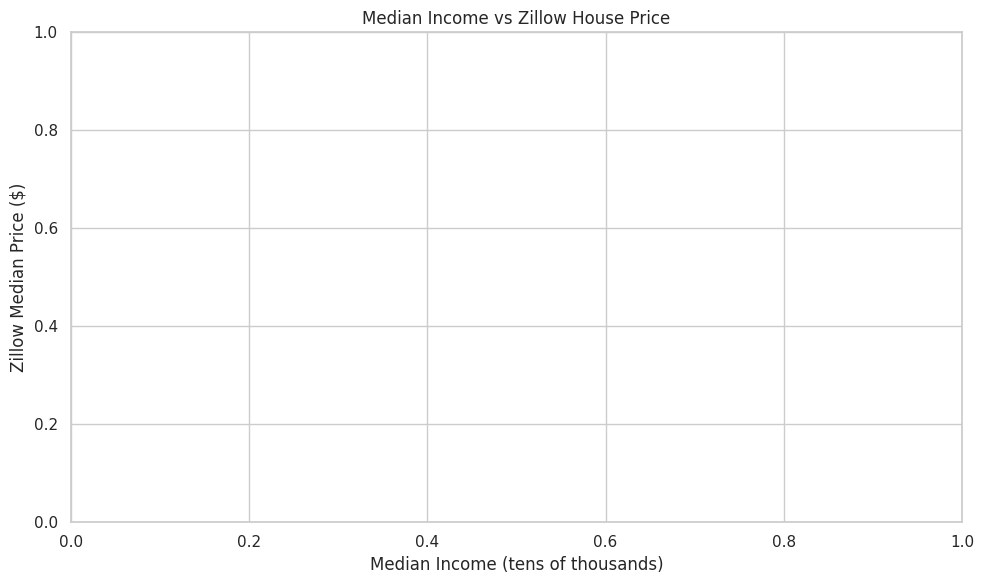

Income vs price scatter plotted


In [21]:
# showing the income vs price plot
# higher income neighborhoods tend to have higher house prices

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x="MedInc",
    y="zillow_median_price",
    alpha=0.3,
    color="steelblue"
)
plt.title("Median Income vs Zillow House Price")
plt.xlabel("Median Income (tens of thousands)")
plt.ylabel("Zillow Median Price ($)")
plt.tight_layout()
plt.savefig("eda_income_vs_price.png")
plt.show()
print("Income vs price scatter plotted")

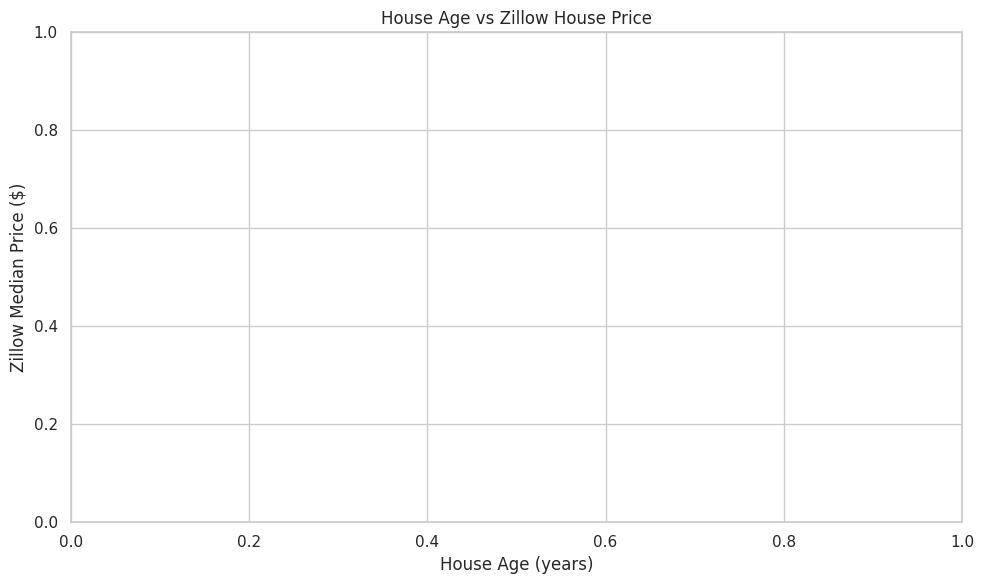

House age vs price scatter plotted


In [22]:
# age of the house vs price plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged,
    x="HouseAge",
    y="zillow_median_price",
    alpha=0.3,
    color="coral"
)
plt.title("House Age vs Zillow House Price")
plt.xlabel("House Age (years)")
plt.ylabel("Zillow Median Price ($)")
plt.tight_layout()
plt.savefig("eda_age_vs_price.png")
plt.show()
print("House age vs price scatter plotted")

In [23]:
# Create a base map centered on California
ca_map = folium.Map(location=[36.7783, -119.4179], zoom_start=6)

# Prepare heatmap data [lat, lon, weight]
heat_data = df_merged[["Latitude", "Longitude", "zillow_median_price"]].dropna()
heat_data = heat_data.values.tolist()

# Add heatmap layer
HeatMap(heat_data, radius=8, blur=10, max_zoom=1).add_to(ca_map)

ca_map.save("eda_ca_heatmap.html")
ca_map

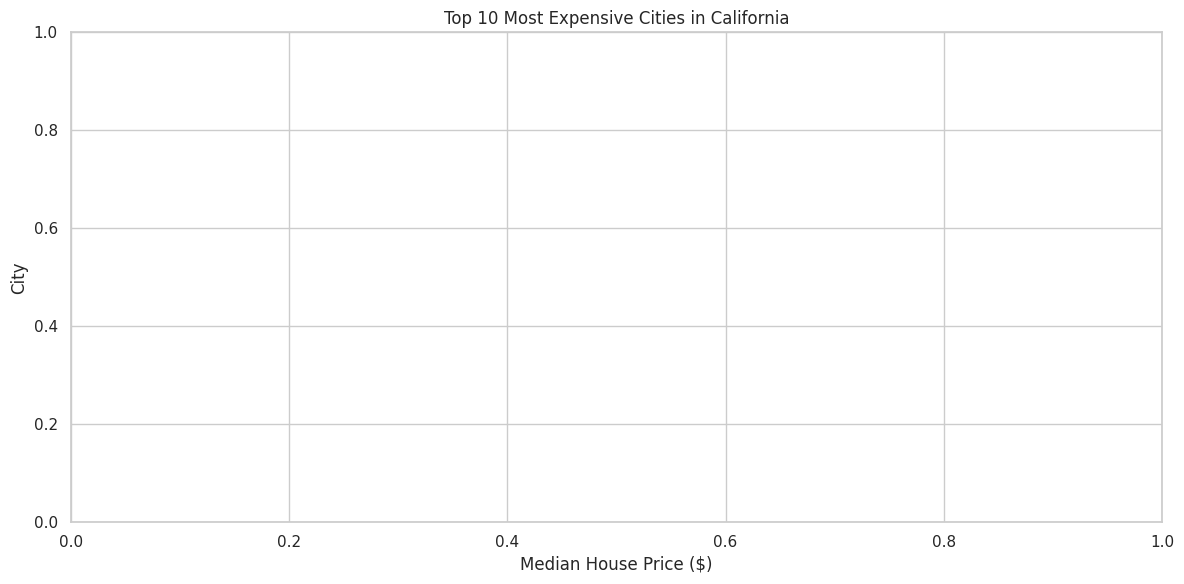

✅ Top cities plotted


In [24]:
# plot for the top most expensive cities

top_cities = (
    df_merged.groupby("city")["zillow_median_price"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.title("Top 10 Most Expensive Cities in California")
plt.xlabel("Median House Price ($)")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("eda_top_cities.png")
plt.show()
print("✅ Top cities plotted")